# Phase 01: Data Collection and Preprocessing

This notebook downloads market data for the **RegimeShift: Macro-Aware Tactical Asset Allocation Engine** project.

The goal of this phase is to create a clean and aligned dataset of asset prices and daily log returns that can be used in later phases for:

- Feature engineering
- HMM-based regime detection
- Portfolio optimization
- Walk-forward backtesting

The asset universe used here includes:

| Ticker | Meaning |
|---|---|
| `^NSEI` | NIFTY 50 index, used as the equity proxy |
| `IEF` | Intermediate-term bond ETF, used as the bond proxy |
| `GLD` | Gold ETF, used as the gold proxy |
| `^VIX` | Volatility index, used as a market stress indicator |


## 1. Imports and Folder Setup

This cell imports the required libraries and creates the required project folders if they do not already exist.

The notebook is written so that it works whether it is run from the project root folder or from inside the `notebooks/` folder.


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path
import os

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

if Path.cwd().name == "notebooks":
    DATA_DIR = Path("../data")
    OUTPUT_DIR = Path("../outputs")
else:
    DATA_DIR = Path("data")
    OUTPUT_DIR = Path("outputs")

DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print("✅ Imports completed")
print(f"Current working directory: {Path.cwd()}")
print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

✅ Imports completed
Current working directory: d:\IITB\RegimeShift\notebooks
Data directory: D:\IITB\RegimeShift\data
Output directory: D:\IITB\RegimeShift\outputs


## 2. Project Configuration

The following tickers and date range are used for the project. The date range can be changed later if required.


In [26]:
TICKERS = ["^NSEI", "IEF", "GLD", "^VIX"]
START_DATE = "2015-01-01"
END_DATE = "2024-01-01"

print(f"Tickers: {TICKERS}")
print(f"Date range: {START_DATE} to {END_DATE}")

Tickers: ['^NSEI', 'IEF', 'GLD', '^VIX']
Date range: 2015-01-01 to 2024-01-01


## 3. Download Market Data

Daily OHLCV data is downloaded using `yfinance`.

`auto_adjust=True` is used so that the prices are adjusted for dividends and splits where applicable.


In [27]:
print(f"Downloading {TICKERS} from {START_DATE} to {END_DATE}...")

raw_data = yf.download(
    TICKERS,
    start=START_DATE,
    end=END_DATE,
    progress=False,
    auto_adjust=True
)

print(f"✅ Downloaded {len(raw_data)} trading days")
print(f"Raw data shape: {raw_data.shape}")
print(f"Column levels: {raw_data.columns.names}")

raw_data.head()

✅ Downloaded 2325 trading days
Raw data shape: (2325, 20)
Column levels: ['Price', 'Ticker']


Price            Close                                           High                                            Low  \
Ticker             GLD        IEF        ^NSEI       ^VIX         GLD        IEF        ^NSEI       ^VIX         GLD   
Date                                                                                                                   
2015-01-02  114.080002  82.595871  8395.450195  17.790001  114.800003  82.696668  8410.599609  20.139999  112.320000   
2015-01-05  115.800003  83.099838  8378.400391  19.920000  116.000000  83.154111  8445.599609  21.290001  114.730003   
2015-01-06  117.120003  83.658104  8127.350098  21.120001  117.500000  84.100042  8327.849609  22.900000  115.800003   
2015-01-07  116.430000  83.642570  8102.100098  19.309999  116.879997  83.743367  8151.200195  20.719999  116.169998   
2015-01-08  115.940002  83.301353  8234.599609  17.010000  116.870003  83.402144  8243.500000  18.090000  115.849998   

Price                                                Open                                         Volume             \
Ticker            IEF        ^NSEI       ^VIX         GLD        IEF        ^NSEI       ^VIX         GLD        IEF   
Date                                                                                                                  
2015-01-02  82.231465  8288.700195  17.049999  112.489998  82.254724  8288.700195  17.760000   7109600.0  2028600.0   
2015-01-05  82.696669  8363.900391  19.190001  114.779999  82.735432  8407.950195  19.190001   8177400.0  1521700.0   
2015-01-06  83.371230  8111.350098  19.520000  116.220001  83.448762  8325.299805  20.330000  11238300.0  1890200.0   
2015-01-07  83.316933  8065.450195  19.040001  116.470001  83.417724  8118.649902  20.150000   6434200.0  1558000.0   
2015-01-08  83.200557  8167.299805  16.990000  116.449997  83.371130  8191.399902  17.930000   7033700.0  1671000.0   

Price                      
Ticker         ^NSEI ^VIX  
Date                       
2015-01-02  101900.0  0.0  
2015-01-05  118200.0  0.0  
2015-01-06  172800.0  0.0  
2015-01-07  164100.0  0.0  
2015-01-08  143800.0  0.0

## 4. Extract Adjusted Close Prices

For this project, the adjusted close price series are used for return calculation and portfolio backtesting.


In [28]:
close_prices = raw_data["Close"].copy()
close_prices.columns.name = None

close_prices = close_prices.rename(
    columns={
        "^NSEI": "NSE",
        "IEF": "IEF",
        "GLD": "GLD",
        "^VIX": "VIX"
    }
)

close_prices = close_prices[["NSE", "IEF", "GLD", "VIX"]]

print("✅ Close prices extracted")
print(close_prices.head())
print("\nMissing values:")
print(close_prices.isna().sum())

✅ Close prices extracted
                    NSE        IEF         GLD        VIX
Date                                                     
2015-01-02  8395.450195  82.595871  114.080002  17.790001
2015-01-05  8378.400391  83.099838  115.800003  19.920000
2015-01-06  8127.350098  83.658104  117.120003  21.120001
2015-01-07  8102.100098  83.642570  116.430000  19.309999
2015-01-08  8234.599609  83.301353  115.940002  17.010000

Missing values:
NSE    112
IEF     61
GLD     61
VIX     61
dtype: int64


## 5. Handle Missing Values and Align Data

Different markets may have different holidays and missing dates.

The data is cleaned by dropping rows where any required asset price is missing. This ensures that all assets are aligned on the same trading dates.


In [29]:
close_prices_clean = close_prices.dropna().copy()

print(f"Rows before cleaning: {len(close_prices)}")
print(f"Rows after cleaning:  {len(close_prices_clean)}")
print(f"Rows dropped:         {len(close_prices) - len(close_prices_clean)}")

close_prices_clean.head()

Rows before cleaning: 2325
Rows after cleaning:  2152
Rows dropped:         173


,NSE,IEF,GLD,VIX
Date,,,,
2015-01-02,8395.450195,82.595871,114.080002,17.790001
2015-01-05,8378.400391,83.099838,115.800003,19.920000
2015-01-06,8127.350098,83.658104,117.120003,21.120001
2015-01-07,8102.100098,83.642570,116.430000,19.309999
2015-01-08,8234.599609,83.301353,115.940002,17.010000


## 6. Compute Daily Log Returns

Log returns are used because they are additive over time and commonly used in quantitative finance.

The VIX is kept as a level because it is a volatility/stress index, not a traded asset in this setup.


In [30]:
ASSET_COLS = ["NSE", "IEF", "GLD"]

asset_returns = np.log(close_prices_clean[ASSET_COLS]).diff()
vix_level = close_prices_clean["VIX"]

master_df = asset_returns.join(vix_level, how="inner").dropna()

print("✅ Master returns dataset created")
print(master_df.head())
print(f"\nFinal dataset shape: {master_df.shape}")

✅ Master returns dataset created
                 NSE       IEF       GLD        VIX
Date                                               
2015-01-05 -0.002033  0.006083  0.014965  19.920000
2015-01-06 -0.030422  0.006696  0.011334  21.120001
2015-01-07 -0.003112 -0.000186 -0.005909  19.309999
2015-01-08  0.016221 -0.004088 -0.004217  17.010000
2015-01-09  0.006042  0.004922  0.011321  17.549999

Final dataset shape: (2151, 4)


## 7. Save Processed Data

The cleaned price data and aligned return dataset are saved to the `data/` folder for use in later phases.


In [31]:
master_df.to_csv(DATA_DIR / "master_returns.csv")
close_prices_clean.to_csv(DATA_DIR / "asset_prices.csv")

print(f"✅ Saved aligned returns to: {DATA_DIR / 'master_returns.csv'}")
print(f"✅ Saved cleaned prices to: {DATA_DIR / 'asset_prices.csv'}")

✅ Saved aligned returns to: ..\data\master_returns.csv
✅ Saved cleaned prices to: ..\data\asset_prices.csv


## 8. Basic Data Inspection

This section performs a quick sanity check on the return data before moving to feature engineering.


In [32]:
print("Summary statistics for asset returns:")
display(master_df[ASSET_COLS].describe())

print("\nCorrelation matrix:")
display(master_df[ASSET_COLS].corr())

Summary statistics for asset returns:


,NSE,IEF,GLD
count,2151.000000,2151.000000,2151.000000
mean,0.000442,0.000030,0.000240
std,0.010816,0.004327,0.009048
min,-0.139038,-0.028557,-0.055190
25%,-0.004476,-0.002400,-0.004674
50%,0.000731,0.000090,0.000497
75%,0.006210,0.002462,0.004969
max,0.084003,0.026074,0.047874



Correlation matrix:


,NSE,IEF,GLD
NSE,1.000000,-0.091587,-0.013326
IEF,-0.091587,1.000000,0.403922
GLD,-0.013326,0.403922,1.000000


## 9. Plot Asset Prices

This plot shows the normalized price movement of the tradable assets.


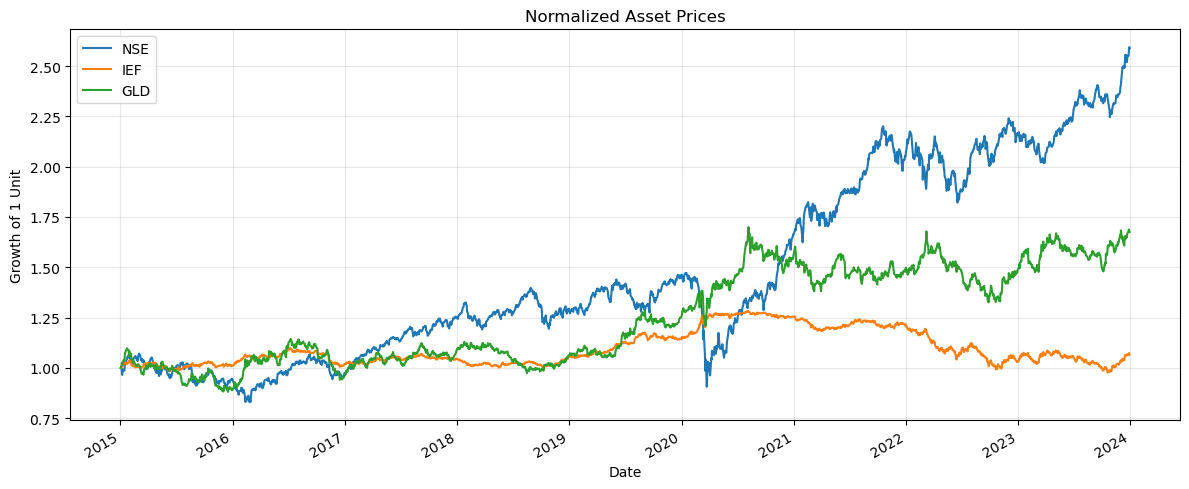

In [33]:
normalized_prices = close_prices_clean[ASSET_COLS] / close_prices_clean[ASSET_COLS].iloc[0]

ax = normalized_prices.plot(figsize=(12, 5))
ax.set_title("Normalized Asset Prices")
ax.set_ylabel("Growth of 1 Unit")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

## 10. Plot Cumulative Returns

The cumulative return chart helps compare how different asset classes behaved over the sample period.


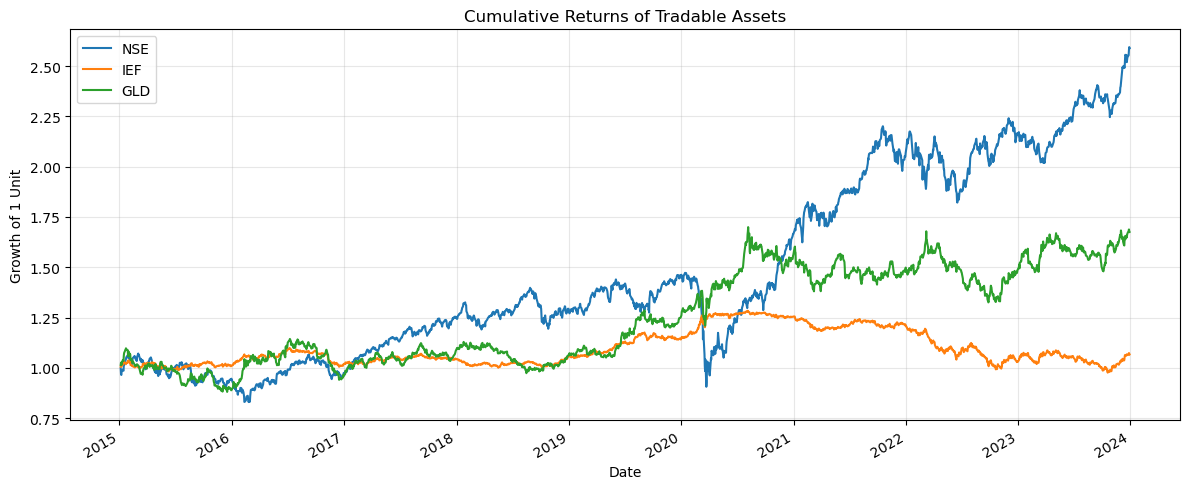

In [34]:
cumulative_returns = np.exp(master_df[ASSET_COLS].cumsum())

ax = cumulative_returns.plot(figsize=(12, 5))
ax.set_title("Cumulative Returns of Tradable Assets")
ax.set_ylabel("Growth of 1 Unit")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

## 11. Plot VIX / Market Stress Indicator

The VIX series is used as a market stress indicator.

High VIX values generally correspond to more uncertain or volatile market conditions.


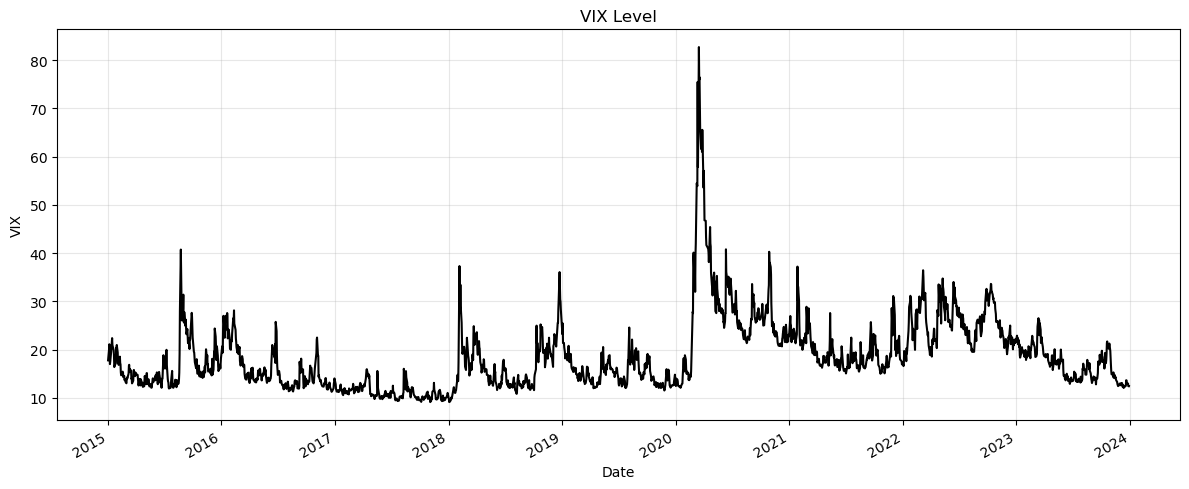

In [35]:
ax = close_prices_clean["VIX"].plot(figsize=(12, 5), color="black")
ax.set_title("VIX Level")
ax.set_ylabel("VIX")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

## 12. Phase 1 Output Summary

This phase generated the following files:

| File | Description |
|---|---|
| `data/asset_prices.csv` | Cleaned adjusted close prices |
| `data/master_returns.csv` | Aligned daily log returns for assets plus VIX level |

These files will be used in Phase 2 for feature engineering.


In [36]:
print("✅ Phase 1 completed successfully.")
print("Generated files:")
print(f"- {DATA_DIR / 'asset_prices.csv'}")
print(f"- {DATA_DIR / 'master_returns.csv'}")

✅ Phase 1 completed successfully.
Generated files:
- ..\data\asset_prices.csv
- ..\data\master_returns.csv
